# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [88]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

In [90]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [91]:
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [92]:
print(f"Dimensão dataset: {df.shape}")

Dimensão dataset: (3150, 14)


In [93]:
TARGET_COLUMN = 'Complains'
print(f"Valores únicos na variável alvo '{TARGET_COLUMN}': {df[TARGET_COLUMN].unique()}")

Valores únicos na variável alvo 'Complains': [0 1]


O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

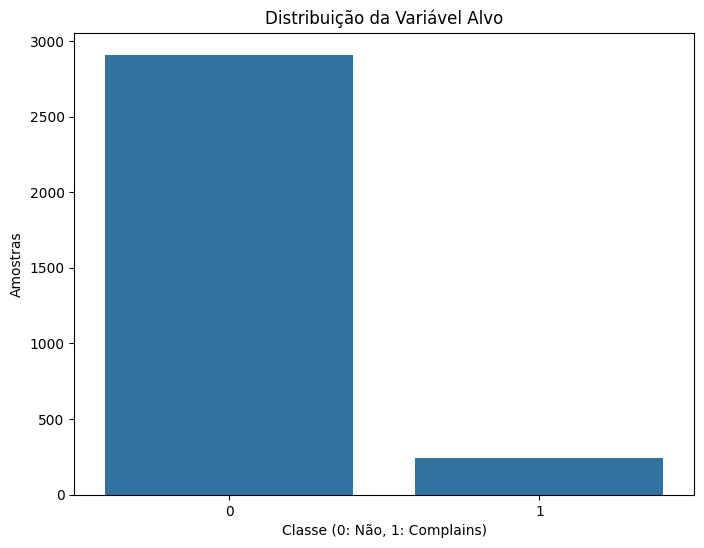

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Complains')
plt.title('Distribuição da Variável Alvo')
plt.xlabel('Classe (0: Não, 1: Complains)')
plt.ylabel('Amostras')
plt.show()

In [95]:
print(df['Complains'].value_counts())

Complains
0    2909
1     241
Name: count, dtype: int64


Com 2.655 amostras na classe 0 e apenas 495 na classe 1, o dataset é considerado desbalanceado. Essa concentração na classe majoritária gera um risco de viés, dificultando a detecção precisa dos casos de Complains (classe 1).

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

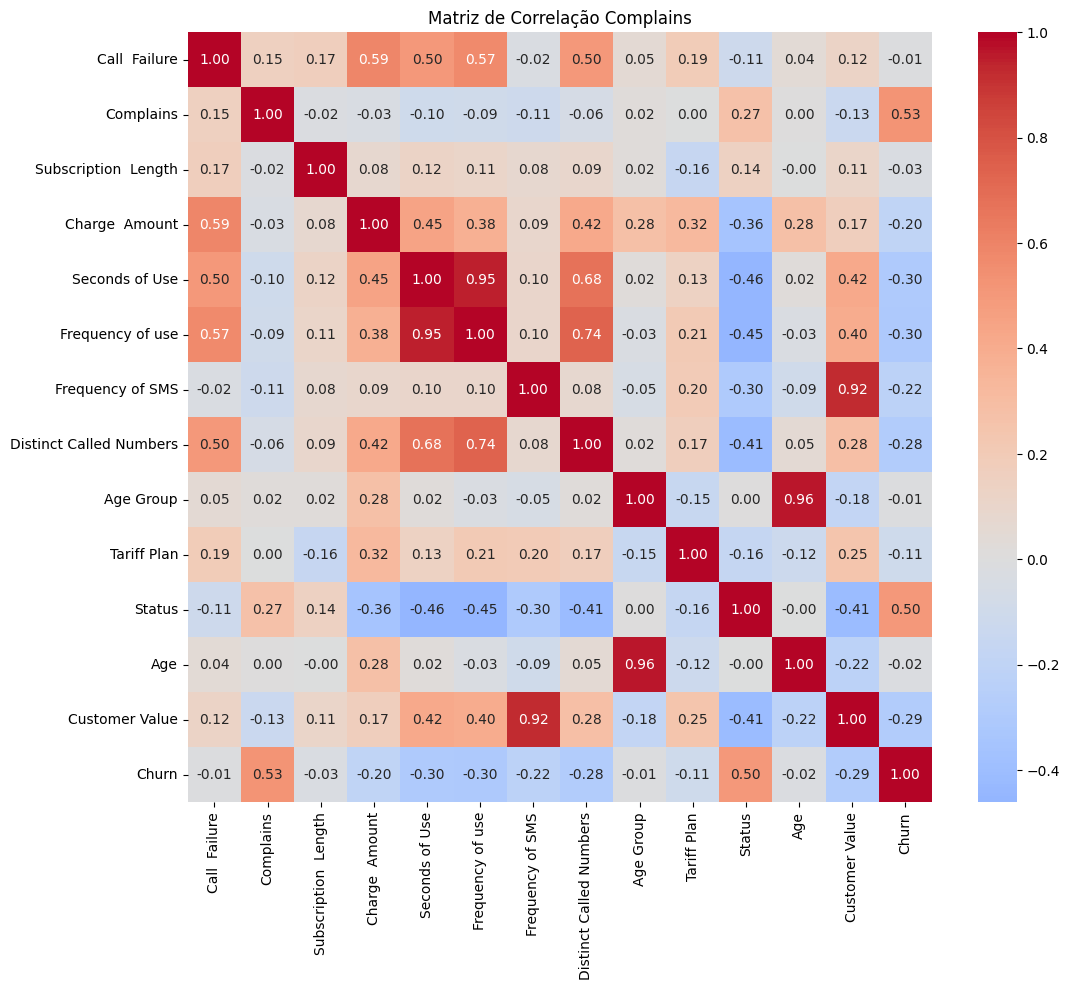

Complains                  1.000000
Churn                      0.532053
Status                     0.271405
Call  Failure              0.152879
Age Group                  0.019976
Age                        0.003298
Tariff Plan                0.001140
Subscription  Length      -0.020286
Charge  Amount            -0.033948
Distinct Called Numbers   -0.058199
Frequency of use          -0.090774
Seconds of Use            -0.104952
Frequency of SMS          -0.111633
Customer Value            -0.132895
Name: Complains, dtype: float64


In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação Complains')
plt.show()

print(correlation_matrix['Complains'].sort_values(ascending=False))

O abandono do serviço (Complains) é impulsionado principalmente por reclamações e pela inatividade do usuário (correlação positiva). Em contrapartida, um alto volume de uso e o valor gerado pelo cliente atuam como fatores de retenção (correlação negativa). Dessa forma, o modelo de classificação encontra seus sinais mais fortes nos atributos Complains, Status, Seconds of Use e Customer Value.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

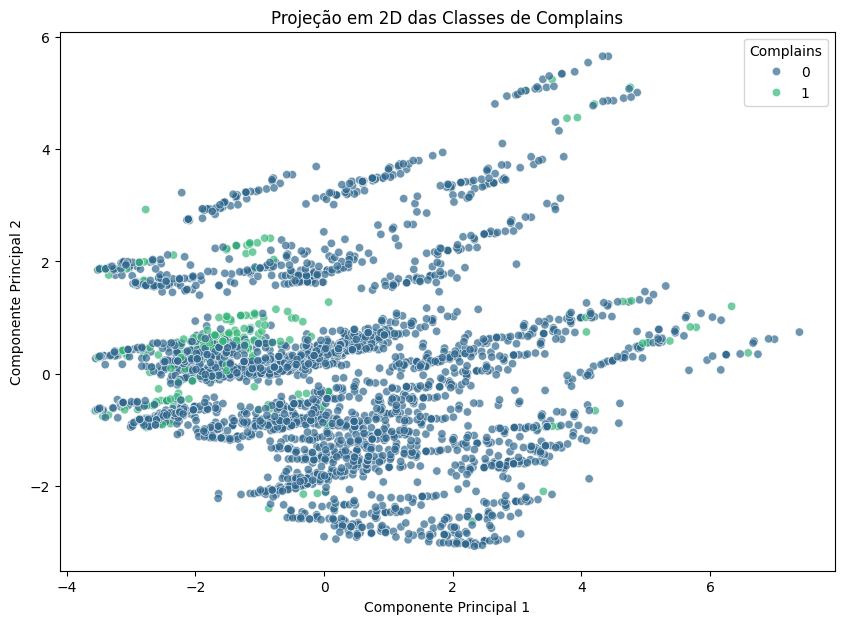

In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=['Complains'])
y = df['Complains']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title('Projeção em 2D das Classes de Complains')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Complains')
plt.show()

Os pontos de Complains e não-Complains aparecem misturados no gráfico, evidenciando que o PCA em 2D é insuficiente para isolar as classes. Essa falta de separação linear indica que o modelo de classificação enfrentará uma fronteira de decisão complexa, exigindo mais do que apenas as componentes principais de maior variância para definir cada grupo.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Complains'])
y = df['Complains']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Padronizar os dados garante que todos os atributos contribuam equitativamente para o aprendizado, eliminando o viés de escala. Ao aplicar o fit exclusivamente no treino, o modelo permanece isolado de informações futuras (vazamento), o que permite uma avaliação realista da sua capacidade de generalização em cenários de produção

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [99]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

if log_reg.n_iter_ < log_reg.max_iter:
    print(f"O modelo convergiu com sucesso em {log_reg.n_iter_[0]} iterações.")
else:
    print("Aviso: O modelo pode não ter convergido.")

O modelo convergiu com sucesso em 22 iterações.


A função do classificador é mapear atributos do consumidor para estimar a probabilidade de Complains, orientando a tomada de decisão estratégica. Durante o ajuste, o modelo calibra pesos para cada variável, quantificando o impacto relativo de fatores operacionais e de uso na transição do cliente para o estado de inatividade.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [100]:
y_probs = log_reg.predict_proba(X_test_scaled)
print("Primeiras 5 probabilidades (Classe 0, Classe 1):")
print(y_probs[:5])

Primeiras 5 probabilidades (Classe 0, Classe 1):
[[0.98293061 0.01706939]
 [0.99359077 0.00640923]
 [0.99814177 0.00185823]
 [0.94338441 0.05661559]
 [0.94643447 0.05356553]]


As saídas são estruturadas em duas colunas representativas das classes 0 e 1, onde a soma de cada linha é igual a 1. A proximidade dos valores com os extremos (0 e 1) revela um modelo com predições incisivas, sugerindo que os atributos utilizados permitem uma separação convicta das amostras na maioria dos casos.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [101]:
import numpy as np

probs_classe_1 = y_probs[:, 1]

y_pred_05 = (probs_classe_1 >= 0.5).astype(int)
y_pred_07 = (probs_classe_1 >= 0.7).astype(int)

print(f"Predições de Complains (limiar 0.5): {np.sum(y_pred_05)}")
print(f"Predições de Complains (limiar 0.7): {np.sum(y_pred_07)}")

Predições de Complains (limiar 0.5): 35
Predições de Complains (limiar 0.7): 3


O ajuste do limiar de decisão altera diretamente o rigor do modelo. Ao elevá-lo (ex: 0.7), prioriza-se a precisão, reduzindo alarmes falsos ao custo de ignorar casos reais de churn. Já a redução do limiar prioriza o recall (sensibilidade), garantindo que mais desistentes sejam capturados, embora isso resulte em mais clientes fiéis sendo classificados erroneamente como riscos.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [102]:
from sklearn.metrics import classification_report, confusion_matrix

def avaliar_modelo(y_true, y_pred, limiar):
    print(f"\n--- Métricas para o Limiar: {limiar} ---")
    print(classification_report(y_true, y_pred))
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))

avaliar_modelo(y_test, y_pred_05, 0.5)
avaliar_modelo(y_test, y_pred_07, 0.7)


--- Métricas para o Limiar: 0.5 ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       581
           1       0.54      0.39      0.45        49

    accuracy                           0.93       630
   macro avg       0.75      0.68      0.71       630
weighted avg       0.92      0.93      0.92       630

Matriz de Confusão:
[[565  16]
 [ 30  19]]

--- Métricas para o Limiar: 0.7 ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       581
           1       1.00      0.06      0.12        49

    accuracy                           0.93       630
   macro avg       0.96      0.53      0.54       630
weighted avg       0.93      0.93      0.90       630

Matriz de Confusão:
[[581   0]
 [ 46   3]]


O Recall é a métrica mais sensível a essa alteração; ao elevar o limiar para 0,7, a capacidade de detecção do modelo cai, deixando passar casos reais de evasão. Esse cenário ilustra o clássico trade-off: ganha-se em Precisão (confiabilidade do alerta) sacrificando o Recall (abrangência da detecção). A decisão estratégica deve ponderar se o custo maior reside em disparar alarmes falsos ou em ignorar clientes prestes a sair.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [103]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [104]:
display(df.head())

print(f"Dimensões do dataset 10% amostrado: {df.shape}")

TARGET_COLUMN = 'Cover_Type'
print(f"\nVariável alvo: '{TARGET_COLUMN}'")
print(f"Valores únicos na variável alvo: {sorted(df[TARGET_COLUMN].unique())}")
print(f"Quantidade de classes: {df[TARGET_COLUMN].nunique()}")

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


Dimensões do dataset 10% amostrado: (58101, 55)

Variável alvo: 'Cover_Type'
Valores únicos na variável alvo: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Quantidade de classes: 7


In [105]:
TARGET_COLUMN = 'Cover_Type' # preencher

O dataset com 10% das amostras possui 58.101 amostras e 55 atributos incluindo
a variável alvo. A Target_column é 'Cover_Type', que representa o tipo de cobertura
florestal. NÃO se trata de um problema de classificação binária: a variável assume
7 valores distintos 1, 2, 3, 4, 5, 6 e 7.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

/tmp/ipykernel_4643/1947227344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=TARGET_COLUMN, palette='viridis')


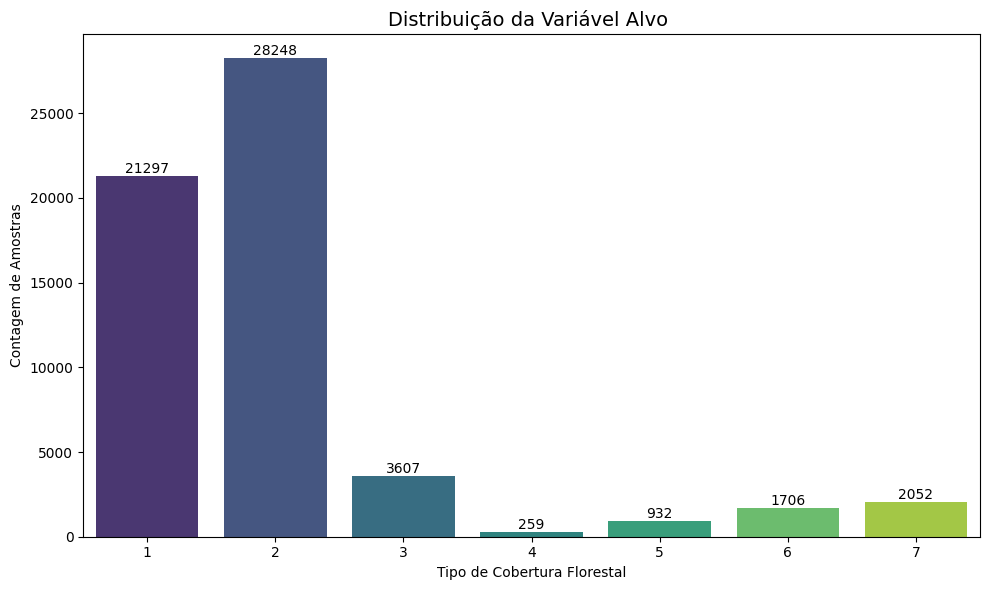

Contagem classe:
Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


In [106]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x=TARGET_COLUMN, palette='viridis')
plt.title('Distribuição da Variável Alvo ', fontsize=14)
plt.xlabel('Tipo de Cobertura Florestal')
plt.ylabel('Contagem de Amostras')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Contagem classe:")
print(df[TARGET_COLUMN].value_counts().sort_index())

O Dataset está desbalanceado, pois as classes não possuem a mesma quantidade de amostras.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

Correlação dos atributos com Cover_Type:
Elevation                            -0.268264
Wilderness_Area1                     -0.200715
Horizontal_Distance_To_Roadways      -0.155258
Soil_Type22                          -0.140253
Soil_Type23                          -0.133668
Soil_Type29                          -0.123732
Horizontal_Distance_To_Fire_Points   -0.109868
Hillshade_Noon                       -0.094159
Soil_Type32                          -0.078483
Soil_Type24                          -0.065993
Soil_Type31                          -0.064168
Soil_Type33                          -0.063686
Hillshade_3pm                        -0.050833
Wilderness_Area2                     -0.048265
Soil_Type19                          -0.039402
Soil_Type20                          -0.030760
Hillshade_9am                        -0.029857
Horizontal_Distance_To_Hydrology     -0.024854
Soil_Type21                          -0.022818
Soil_Type12                          -0.022214
Soil_Type30        

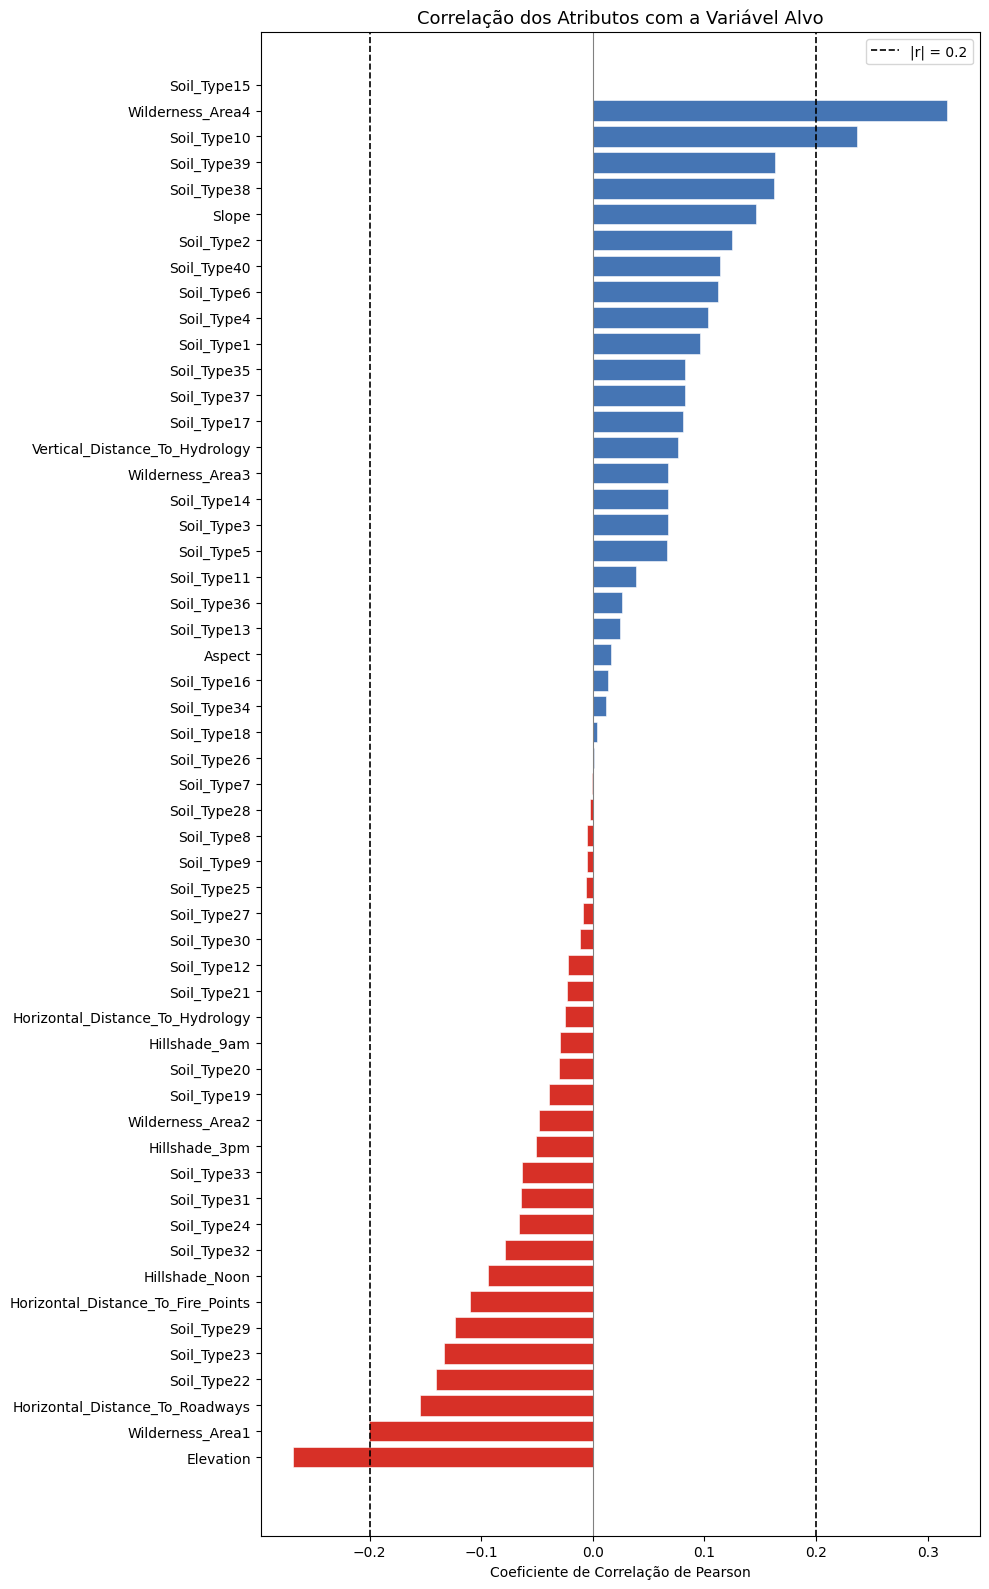

In [107]:
correlation = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values()

print("Correlação dos atributos com Cover_Type:")
print(correlation.to_string())

plt.figure(figsize=(10, 16))
colors = ['#d73027' if v < 0 else '#4575b4' for v in correlation]
bars = plt.barh(correlation.index, correlation.values, color=colors, edgecolor='white', linewidth=0.4)

plt.axvline(x=0.2,  color='black', linestyle='--', linewidth=1.2, label='|r| = 0.2')
plt.axvline(x=-0.2, color='black', linestyle='--', linewidth=1.2)
plt.axvline(x=0,    color='gray',  linestyle='-',  linewidth=0.8)

plt.title('Correlação dos Atributos com a Variável Alvo', fontsize=13)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

Variância explicada PC1: 6.95%, PC2: 5.52%, Total: 12.47%


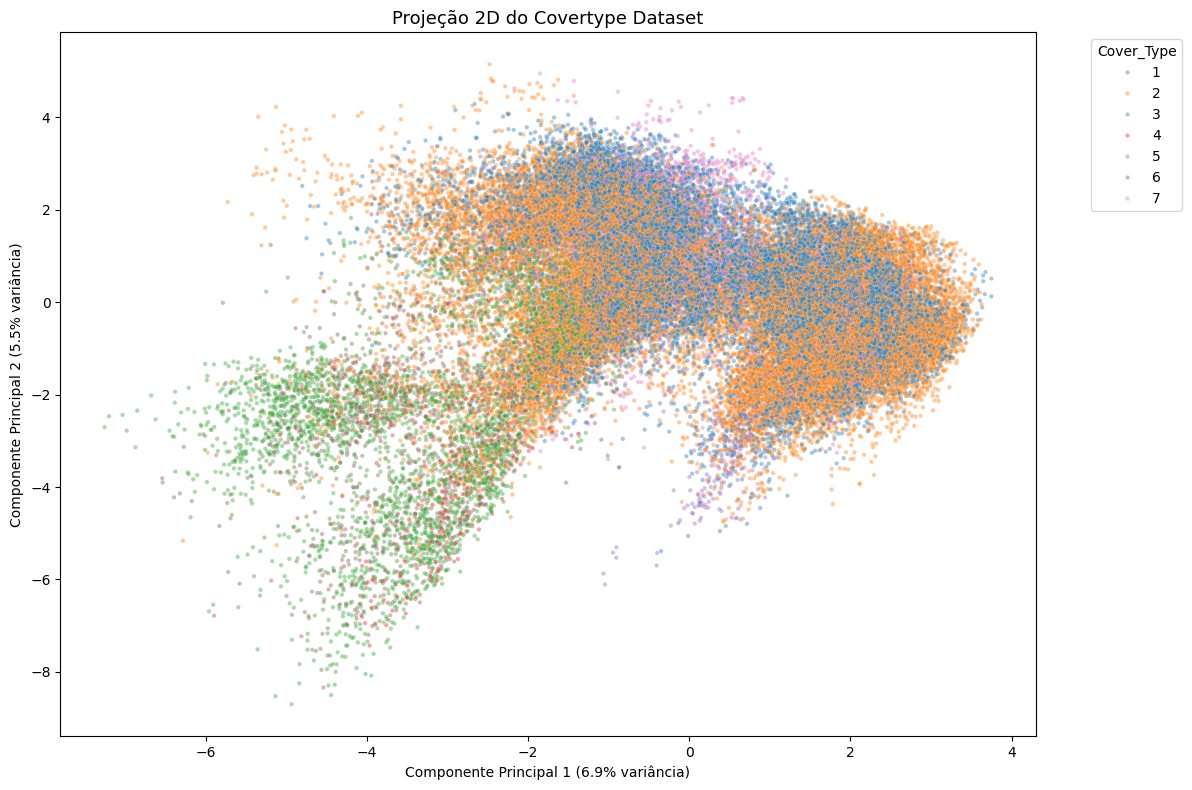

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_pca_input = df.drop(columns=[TARGET_COLUMN])
y_pca_input = df[TARGET_COLUMN]

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled_pca)

variancia = pca.explained_variance_ratio_
print(f"Variância explicada PC1: {variancia[0]:.2%}, PC2: {variancia[1]:.2%}, "
      f"Total: {sum(variancia):.2%}")

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x=X_2d[:, 0], y=X_2d[:, 1],
    hue=y_pca_input,
    palette='tab10',
    alpha=0.4,
    s=10,
    legend='full'
)
plt.title('Projeção 2D do Covertype Dataset', fontsize=13)
plt.xlabel(f'Componente Principal 1 ({variancia[0]:.1%} variância)')
plt.ylabel(f'Componente Principal 2 ({variancia[1]:.1%} variância)')
plt.legend(title='Cover_Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Conseguimos analisar que não há uma separação entre as classes nos componentes principais. Isso indica que a fronteira de decisão é altamente não-linear e
multidimensional, exigindo modelos mais complexos ou mais componentes para uma
separação eficaz.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [109]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do treino : {X_train.shape}")
print(f"Tamanho do teste  : {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

Tamanho do treino : (46480, 54)
Tamanho do teste  : (11621, 54)


A validação é importante porque com ela conseguimos analisar se tem overfitting e fornecer estimativas mais robustas.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
)

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

results = cross_validate(pipeline, X_train, y_train, cv=kf, scoring=scoring)

print("=" * 40)
print(f"{'Métrica':<15} | {'Média ± Desvio':<20}")
print("-" * 40)
for metric in scoring:
    vals = results[f'test_{metric}']
    print(f"{metric:<15} | {vals.mean():.4f} ± {vals.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was 

Métrica         | Média ± Desvio      
----------------------------------------
accuracy        | 0.7263 ± 0.0053
precision_weighted | 0.7127 ± 0.0066
recall_weighted | 0.7263 ± 0.0053
f1_weighted     | 0.7160 ± 0.0046


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Objetivo: O modelo utiliza 54 atributos geográficos para calcular a probabilidade de uma parcela de terra pertencer a um dos 7 tipos de cobertura florestal.

Aprendizado: Ele define pesos que identificam quais variáveis melhor distinguem cada espécie.

Validação: O foco é usar a validação cruzada para garantir que esses padrões funcionem em novos terrenos, e não apenas nos dados já vistos.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [111]:
from sklearn.linear_model import LogisticRegression

log_l2 = LogisticRegression(
    penalty='l2',
    C=0.01,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
log_l2.fit(X_train_scaled, y_train)

print(f"Convergiu: {log_l2.n_iter_[0] < log_l2.max_iter} "
      f"(iterações: {log_l2.n_iter_[0]})")

y_probs_l2 = log_l2.predict_proba(X_test_scaled)

print("\nPrimeiras 5 probabilidades previstas:")
print("Colunas = classes:", log_l2.classes_)
print(np.round(y_probs_l2[:5], 4))

Convergiu: True (iterações: 92)

Primeiras 5 probabilidades previstas:
Colunas = classes: [1 2 3 4 5 6 7]
[[4.170e-02 9.432e-01 4.000e-04 2.000e-04 1.060e-02 3.300e-03 5.000e-04]
 [2.829e-01 6.934e-01 7.000e-04 1.000e-04 8.800e-03 7.400e-03 6.700e-03]
 [4.114e-01 5.793e-01 1.000e-04 1.000e-04 7.300e-03 6.000e-04 1.100e-03]
 [1.068e-01 8.475e-01 3.000e-04 4.000e-04 4.160e-02 1.000e-03 2.200e-03]
 [8.360e-02 8.922e-01 1.000e-04 2.000e-04 2.020e-02 1.400e-03 2.300e-03]]


Cada linha contém 7 probabilidades (uma por classe), que somam 1.0 para cada amostra.
A coluna i corresponde à probabilidade de pertencer à classe log_l2.classes_[i].

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [112]:
log_no_reg = LogisticRegression(
    penalty=None,
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)
log_no_reg.fit(X_train_scaled, y_train)

print(f"Convergiu: {log_no_reg.n_iter_[0] < log_no_reg.max_iter} "
      f"(iterações: {log_no_reg.n_iter_[0]})")

y_probs_no_reg = log_no_reg.predict_proba(X_test_scaled)

print("\nPrimeiras 5 probabilidades previstas: ")
print("Colunas = classes: ", log_no_reg.classes_)
print(np.round(y_probs_no_reg[:5], 4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Convergiu: True (iterações: 214)

Primeiras 5 probabilidades previstas: 
Colunas = classes:  [1 2 3 4 5 6 7]
[[2.850e-02 9.563e-01 0.000e+00 0.000e+00 1.510e-02 0.000e+00 0.000e+00]
 [2.696e-01 7.180e-01 0.000e+00 0.000e+00 7.600e-03 4.500e-03 2.000e-04]
 [3.786e-01 6.137e-01 0.000e+00 0.000e+00 7.600e-03 0.000e+00 0.000e+00]
 [9.140e-02 8.714e-01 0.000e+00 0.000e+00 3.720e-02 0.000e+00 0.000e+00]
 [6.960e-02 9.122e-01 0.000e+00 0.000e+00 1.820e-02 0.000e+00 0.000e+00]]


### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

Confiança Média
COM regularização L2: 0.7033
SEM regularização: 0.7270


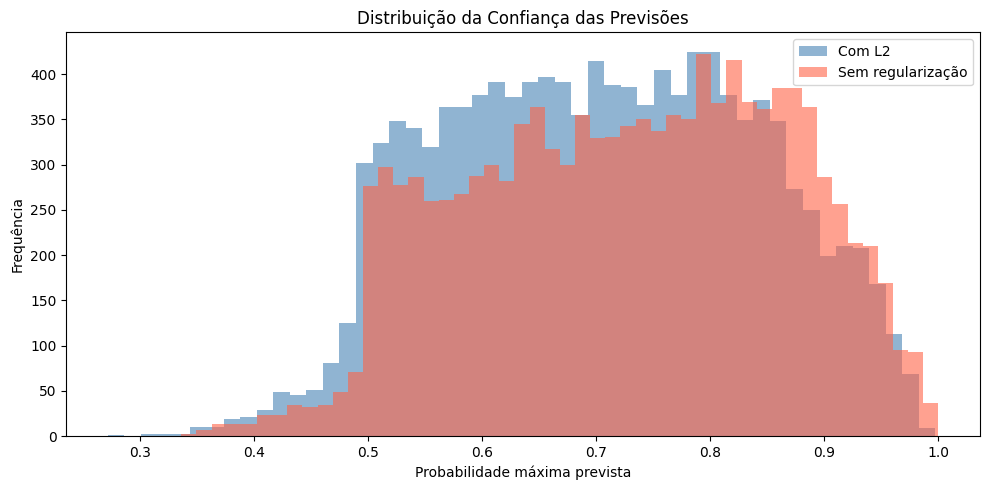

In [113]:
confianca_l2     = y_probs_l2.max(axis=1)
confianca_no_reg = y_probs_no_reg.max(axis=1)

print("Confiança Média")
print(f"COM regularização L2: {confianca_l2.mean():.4f}")
print(f"SEM regularização: {confianca_no_reg.mean():.4f}")

plt.figure(figsize=(10, 5))
plt.hist(confianca_l2, bins=50, alpha=0.6, label='Com L2 ', color='steelblue')
plt.hist(confianca_no_reg, bins=50, alpha=0.6, label='Sem regularização', color='tomato')
plt.title('Distribuição da Confiança das Previsões')
plt.xlabel('Probabilidade máxima prevista')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [114]:
from sklearn.metrics import classification_report

y_pred_l2     = log_l2.predict(X_test_scaled)
y_pred_no_reg = log_no_reg.predict(X_test_scaled)

print("=" * 60)
print("Classification Report COM regularização L2")
print("=" * 60)
print(classification_report(y_test, y_pred_l2, zero_division=0))

print("=" * 60)
print("Classification Report SEM regularização")
print("=" * 60)
print(classification_report(y_test, y_pred_no_reg, zero_division=0))

Classification Report COM regularização L2
              precision    recall  f1-score   support

           1       0.72      0.69      0.70      4260
           2       0.74      0.80      0.77      5650
           3       0.64      0.85      0.73       722
           4       0.46      0.21      0.29        52
           5       0.00      0.00      0.00       186
           6       0.48      0.14      0.22       341
           7       0.73      0.57      0.64       410

    accuracy                           0.72     11621
   macro avg       0.54      0.47      0.48     11621
weighted avg       0.70      0.72      0.71     11621

Classification Report SEM regularização
              precision    recall  f1-score   support

           1       0.72      0.70      0.71      4260
           2       0.75      0.80      0.77      5650
           3       0.68      0.79      0.73       722
           4       0.51      0.42      0.46        52
           5       0.00      0.00      0.00      

Com Regularização C=0.01: O modelo é mais conservador. Isso evita o overfitting, mas prejudica as classes raras (minorias).

Sem Regularização: O modelo tem mais liberdade. Ele consegue "memorizar" melhor os dados, o que pode aumentar as métricas nas classes raras no curto prazo, mas gera instabilidade e risco de não generalizar para dados novos.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

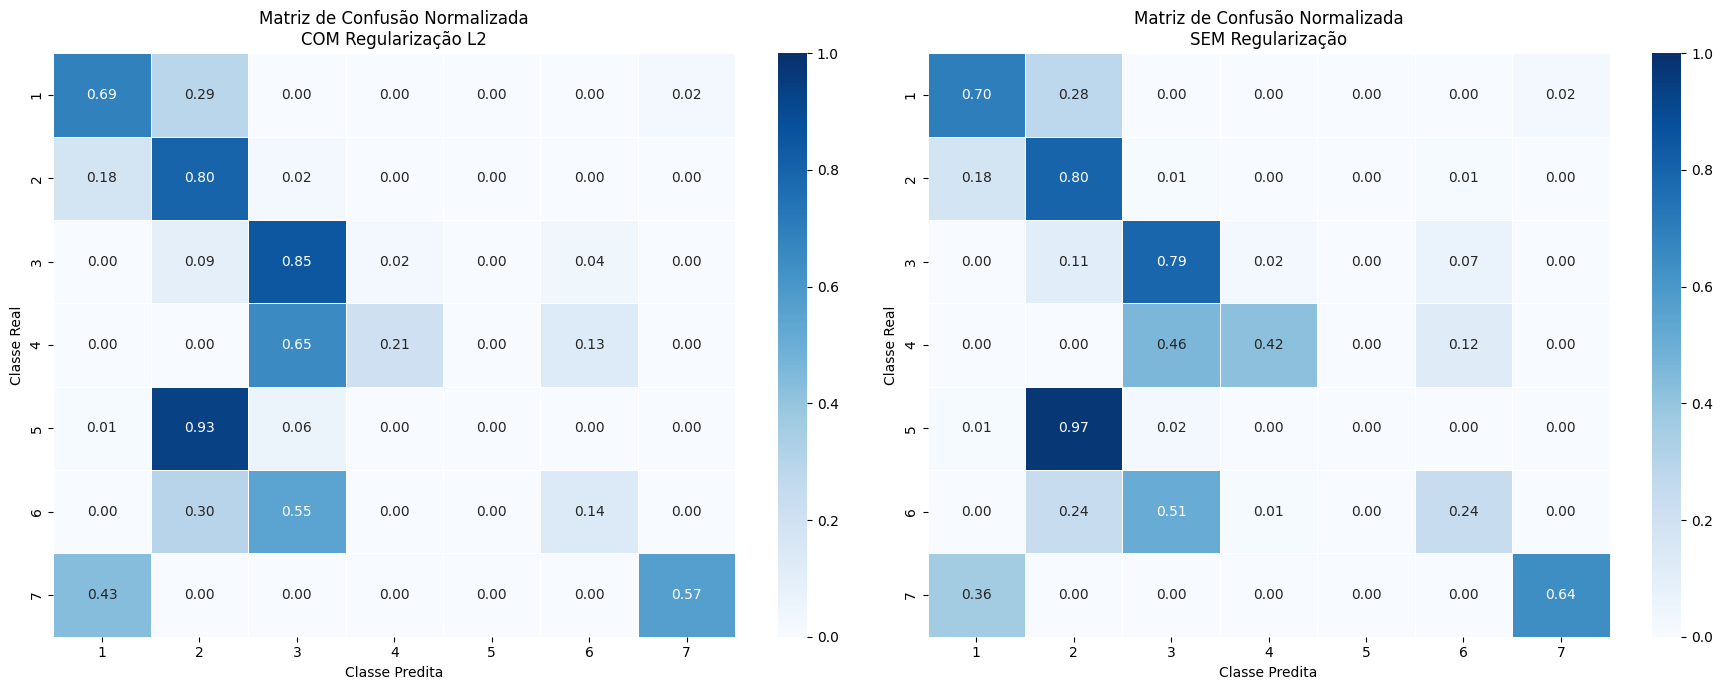

In [115]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes = sorted(y_test.unique())

cm_l2 = confusion_matrix(y_test, y_pred_l2, labels=classes, normalize='true')
cm_no_reg = confusion_matrix(y_test, y_pred_no_reg, labels=classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, title in zip(
    axes,
    [cm_l2, cm_no_reg],
    ['COM Regularização L2', 'SEM Regularização']
):
    sns.heatmap(
        np.round(cm, 2),
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        vmin=0, vmax=1,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f'Matriz de Confusão Normalizada\n{title}', fontsize=12)
    ax.set_xlabel('Classe Predita')
    ax.set_ylabel('Classe Real')

plt.tight_layout()
plt.show()

Classes Majoritárias (1 e 2): Possuem o maior recall devido à abundância de dados, sendo as referências de acerto do modelo.

Classes Minoritárias (3 a 7): Sofrem mais confusão, sendo frequentemente classificadas incorretamente entre si ou "empurradas" para as classes dominantes.

Efeito L2: A regularização forte tende a priorizar as classes majoritárias, aumentando o erro nas raras.

Sem Regularização: Oferece um recall potencialmente melhor nas minorias, mas com maior risco de o modelo apenas decorar o ruído dos dados (overfitting).